In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
observations = 1000

xs = np.random.uniform(10,-10,(observations,1))
zs = np.random.uniform(10,-10,(observations,1))

generated_inputs = np.column_stack((xs,zs))

noise = np.random.uniform(-1,1,(observations,1))

generated_targets = 2*xs - 3*zs + 5 + noise

np.savez('TF_intro', inputs = generated_inputs,targets=generated_targets)

In [4]:
# Tensorflow を使った実装

In [5]:
training_data = np.load('TF_intro.npz')

In [28]:
input_size =2
output_size =1

# make model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size,
                          kernel_initializer=tf.random_uniform_initializer(minval=-0.1,maxval=0.1),
                          bias_initializer=tf.random_uniform_initializer(minval=-0.1,maxval=0.1)
    )
])

custom_optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)



model.compile(optimizer=custom_optimizer,loss='mean_squared_error')

model.fit(training_data['inputs'],training_data['targets'],epochs=100,verbose=2)

Epoch 1/100
32/32 - 0s - 13ms/step - loss: 27.6246
Epoch 2/100
32/32 - 0s - 3ms/step - loss: 1.2053
Epoch 3/100
32/32 - 0s - 3ms/step - loss: 0.5218
Epoch 4/100
32/32 - 0s - 3ms/step - loss: 0.3914
Epoch 5/100
32/32 - 0s - 3ms/step - loss: 0.4172
Epoch 6/100
32/32 - 0s - 3ms/step - loss: 0.3667
Epoch 7/100
32/32 - 0s - 5ms/step - loss: 0.3983
Epoch 8/100
32/32 - 0s - 9ms/step - loss: 0.3915
Epoch 9/100
32/32 - 0s - 5ms/step - loss: 0.3910
Epoch 10/100
32/32 - 0s - 6ms/step - loss: 0.4303
Epoch 11/100
32/32 - 0s - 5ms/step - loss: 0.4008
Epoch 12/100
32/32 - 0s - 4ms/step - loss: 0.3951
Epoch 13/100
32/32 - 0s - 5ms/step - loss: 0.3925
Epoch 14/100
32/32 - 0s - 5ms/step - loss: 0.4367
Epoch 15/100
32/32 - 0s - 5ms/step - loss: 0.3727
Epoch 16/100
32/32 - 0s - 6ms/step - loss: 0.3956
Epoch 17/100
32/32 - 0s - 5ms/step - loss: 0.3616
Epoch 18/100
32/32 - 0s - 5ms/step - loss: 0.3720
Epoch 19/100
32/32 - 0s - 5ms/step - loss: 0.3606
Epoch 20/100
32/32 - 0s - 5ms/step - loss: 0.3971
Epoch 2

In [8]:
# 重みとバイアスの出力

In [29]:
model.layers[0].get_weights()

[array([[ 1.932134 ],
        [-2.9874756]], dtype=float32),
 array([5.0457473], dtype=float32)]

In [30]:
weights = model.layers[0].get_weights()[0]
weights

array([[ 1.932134 ],
       [-2.9874756]], dtype=float32)

In [31]:
biases = model.layers[0].get_weights()[1]
print('biases=',biases)

biases= [5.0457473]


In [13]:
#出力データの抽出

In [32]:
model.predict_on_batch(training_data['inputs']).round(1)

array([[ -4.7],
       [  3. ],
       [-37.9],
       [-32.5],
       [ 24.3],
       [  8.8],
       [ 25. ],
       [ 29.1],
       [  3.6],
       [ 28.6],
       [ 27.9],
       [  8.5],
       [ 30.5],
       [ 12.4],
       [  2.8],
       [ 31.7],
       [  9.1],
       [ 35.4],
       [ 32.4],
       [ 11.5],
       [  9.5],
       [  1.7],
       [ 13. ],
       [ -9.2],
       [ 17.2],
       [-15.5],
       [-19.6],
       [-11.3],
       [ 35.1],
       [-12.5],
       [ 16.8],
       [-36.4],
       [ -2.9],
       [-13.9],
       [ 10.4],
       [ 30.4],
       [ 24.4],
       [-19.3],
       [-14.8],
       [ 22.8],
       [-25.7],
       [ 15.5],
       [-23. ],
       [ -5.4],
       [ 26.4],
       [ 14. ],
       [-15.9],
       [ -2.4],
       [ -1.7],
       [ 18.2],
       [  5.9],
       [ -6.4],
       [  1.1],
       [ 12. ],
       [ 16. ],
       [ 14.3],
       [-27.6],
       [ -4.8],
       [-19.8],
       [ 26.1],
       [ 20.9],
       [-31.7],
       [

In [34]:
pred = model.predict_on_batch(training_data['inputs']).round(1)
type(pred)

numpy.ndarray

In [35]:
training_data['targets'].round(1)

array([[ -4.4],
       [  4.2],
       [-38.4],
       [-32.5],
       [ 23.6],
       [  8.5],
       [ 25.5],
       [ 29.4],
       [  3.1],
       [ 29.2],
       [ 28.6],
       [  9. ],
       [ 30.1],
       [ 13. ],
       [  2. ],
       [ 31.4],
       [ 10.3],
       [ 36.2],
       [ 32.8],
       [ 10.6],
       [  9.9],
       [  2.3],
       [ 11.8],
       [-10.2],
       [ 17.4],
       [-16.1],
       [-20.5],
       [-10.7],
       [ 34.8],
       [-12.5],
       [ 16.6],
       [-36.5],
       [ -2.7],
       [-12.8],
       [ 10.8],
       [ 31.5],
       [ 25.3],
       [-19.6],
       [-14.5],
       [ 23. ],
       [-25.5],
       [ 14.9],
       [-23.4],
       [ -6. ],
       [ 26.8],
       [ 14.9],
       [-16.9],
       [ -3.1],
       [ -2.2],
       [ 17.7],
       [  6.1],
       [ -7.7],
       [  1.3],
       [ 11.5],
       [ 16.1],
       [ 14. ],
       [-28.7],
       [ -5.4],
       [-20.4],
       [ 25.8],
       [ 20. ],
       [-32.1],
       [

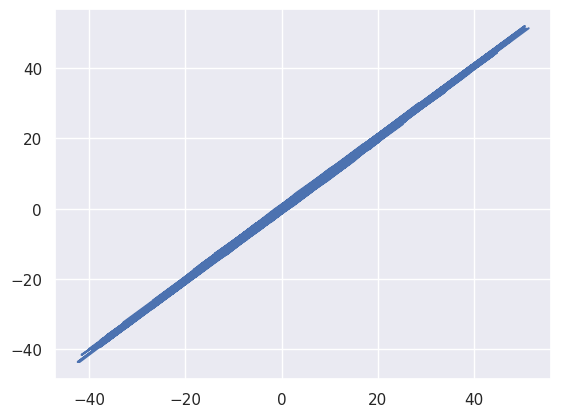

In [36]:
# Plot Scatter
import seaborn as sns
sns.set()

plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])),np.squeeze(training_data['targets']))

plt.show()